<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,SGDRegressor

In [2]:
X = 6 * np.random.rand(200,1) -3
y = 0.8 * X**2 + 0.9* X +2+ np.random.randn(200,1)

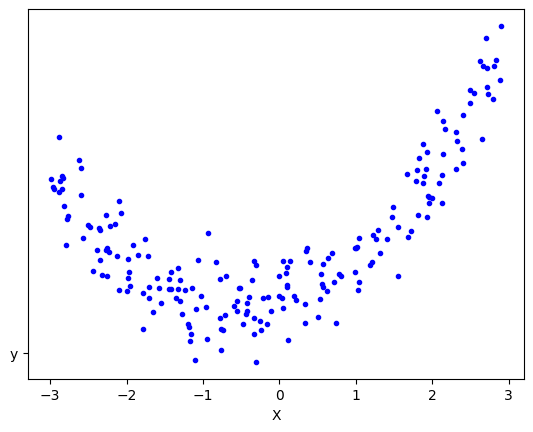

In [3]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.plot("y")
plt.show()

In [5]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [7]:
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.276703898178429

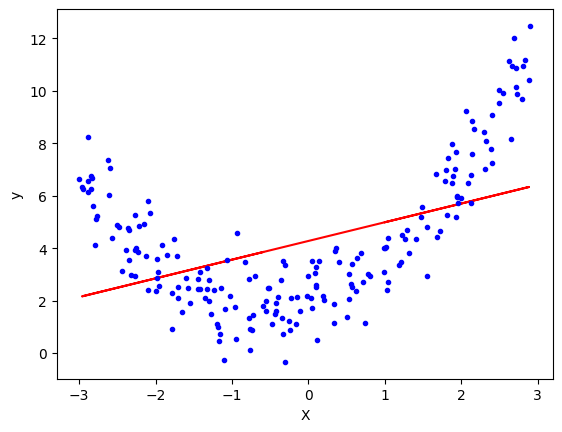

In [10]:
plt.plot(x_train,lr.predict(x_train),color='red')
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [11]:
# Applying Polynomial Linear Regression
poly = PolynomialFeatures(degree=2)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [12]:
print(x_train[0])

[-0.59465689]


In [13]:
print(x_train_trans[0])

[ 1.         -0.59465689  0.35361681]


In [14]:
lr= LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(x_test_trans)
r2_score(y_test,y_pred)

0.8672088034331847

In [16]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.83650245 0.81628033]]
[1.89390178]


In [17]:
x_new =np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

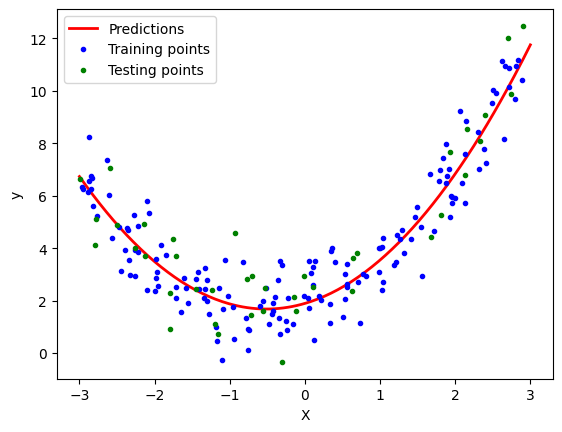

In [19]:
plt.plot(x_new,y_new,"r-",linewidth=2,label='Predictions')
plt.plot(x_train,y_train,"b.",label='Training points')
plt.plot(x_test,y_test,"g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [20]:
def polynomial_regression(degree):
  x_new = np.linspace(-3,3,100).reshape(100,1)
  x_new_poly = poly.transform(x_new)

  polybig_features = PolynomialFeatures(degree=degree,include_bias=False)
  std_scaler = StandardScaler()
  lin_reg = LinearRegression()
  polynomial_regression = Pipeline([
      ("poly_features",polybig_features),
      ("std_scaler",std_scaler),
      ("lin_reg",lin_reg)
  ])
  polynomial_regression.fit(x_train,y_train)
  y_newbig = polynomial_regression.predict(x_new)
  plt.plot(x_new,y_newbig,'r',label="Degree "+ str(degree), linewidth=2)

  plt.plot(x_train,y_train,"b.",linewidth=3)
  plt.plot(x_test,y_test,"g.",linewidth=3)
  plt.legend(loc='upper left')
  plt.xlabel("X")
  plt.ylabel("y")
  plt.axis([-3,3,0,10])
  plt.show()

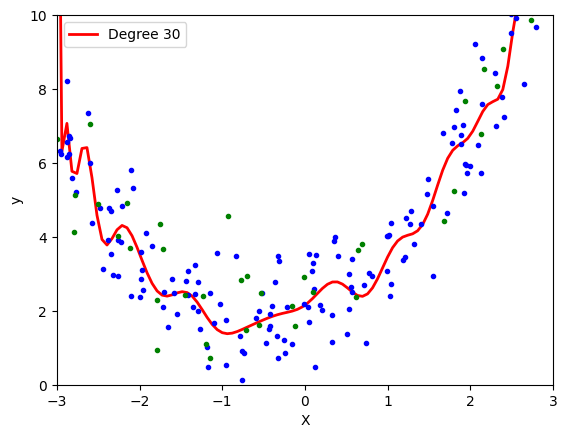

In [27]:
polynomial_regression(30)

In [28]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [29]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()

In [31]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(),x.max(),10)
y_input = np.linspace(y.min(),y.max(),10)
xGrid,yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [32]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [33]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [35]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [37]:
print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Ouput 496
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0]
 [13  1]
 [12  2]
 [

In [38]:
X_multi_trans.shape

(100, 496)

In [39]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [40]:
X_test_multi = poly.transform(final)

In [41]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [42]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()